# Sales Analysis

In [108]:

pip install pandas scikit-learn xgboost matplotlib seaborn imblearn


Note: you may need to restart the kernel to use updated packages.


In [109]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold, cross_val_predict
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

#  Employee Turnover Analytics

# Project statement:

Portobello Tech is an app innovator who has devised an intelligent way of predicting employee turnover within the company. It periodically evaluates employees' work details, including the number of projects they worked on, average monthly working hours, time spent in the company, promotions in the last five years, and salary level.
Data from prior evaluations shows the employees’ satisfaction in the workplace. The data could be used to identify patterns in work style and their interest in continuing to work for the company. 
The HR Department owns the data and uses it to predict employee turnover. Employee turnover refers to the total number of workers who leave a company over time.
As the ML Developer assigned to the HR Department, you have been asked to create ML programs to:
1.	Perform data quality checks by checking for missing values, if any.
2.	Understand what factors contributed most to employee turnover at EDA.
3.	Perform clustering of employees who left based on their satisfaction and evaluation.
4.	Handle the left Class Imbalance using the SMOTE technique.
5.	Perform k-fold cross-validation model training and evaluate performance. 
6.	Identify the best model and justify the evaluation metrics used. 
7.	Suggest various retention strategies for targeted employees.



## Data Wrangling
- Inspect the data manually to identify missing or incorrect information using the functions isna() and notna().
- Based on your knowledge of data analytics, include your recommendations for treating missing and incorrect data (dropping the null values or filling them).
-	Choose a suitable data wrangling technique—either data standardization or normalization. Execute the preferred normalization method and present the resulting data. (Normalization is the preferred approach for this problem.)


In [110]:
df = pd.read_csv('HR_comma_sep.csv')
print(f"\nhead\n", df.head())
#print(f"\ntail\n",df.tail())


head
    satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   

   time_spend_company  Work_accident  left  promotion_last_5years  sales  \
0                   3              0     1                      0  sales   
1                   6              0     1                      0  sales   
2                   4              0     1                      0  sales   
3                   5              0     1                      0  sales   
4                   3              0     1                      0  sales   

   salary  
0     low  
1  medium  
2  medium  
3     l

In [111]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  str    
 9   salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.1 MB


In [112]:


df.drop(['sales'], axis=1, inplace=True)

cat_features=df.select_dtypes(include=["object"]).columns
numeric_features=df.select_dtypes(include=["int64","float64"]).columns
print("Categorical features")
print(cat_features.to_list())
print("Numeric features")
print(numeric_features.to_list())

for col in cat_features:
    print(f"{col}:\n",df[col].value_counts())

for col in numeric_features:
    if col != "Sales":
        print(f"{col}:\n",df[col].value_counts())



Categorical features
['salary']
Numeric features
['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'left', 'promotion_last_5years']
salary:
 salary
low       7316
medium    6446
high      1237
Name: count, dtype: int64
satisfaction_level:
 satisfaction_level
0.10    358
0.11    335
0.74    257
0.77    252
0.84    247
       ... 
0.25     34
0.28     31
0.27     30
0.12     30
0.26     30
Name: count, Length: 92, dtype: int64
last_evaluation:
 last_evaluation
0.55    358
0.50    353
0.54    350
0.51    345
0.57    333
       ... 
0.39     52
0.43     50
0.38     50
0.44     44
0.36     22
Name: count, Length: 65, dtype: int64
number_project:
 number_project
4    4365
3    4055
5    2761
2    2388
6    1174
7     256
Name: count, dtype: int64
average_montly_hours:
 average_montly_hours
135    153
156    153
149    148
151    147
160    136
      ... 
297      7
288      6
299      6
303      6
96       6
Name: count

/var/folders/_4/j16l6rt17n1962v_24706dwr0000gr/T/ipykernel_47291/2850787165.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features=df.select_dtypes(include=["object"]).columns


In [113]:
df.duplicated().sum()

np.int64(3040)

In [114]:
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [115]:
print(df.shape)
print(df.columns)


(14999, 9)
Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'salary'],
      dtype='str')


** Observations **
- Has 14999 rows and 9 columns

In [116]:
df.nunique()

satisfaction_level        92
last_evaluation           65
number_project             6
average_montly_hours     215
time_spend_company         8
Work_accident              2
left                       2
promotion_last_5years      2
salary                     3
dtype: int64

** Observations **
- The dataset contains employee information with the following key features:
- **satisfaction_level**: Employee satisfaction score (0-1 scale)
- **last_evaluation**: Last performance evaluation score
- **average_montly_hours**: Average monthly working hours
- **number_project**: Number of projects completed
- **time_spend_company**: Years spent at the company
- **Work_accident**: Whether the employee had a work accident (0 or 1)
- **left**: Whether the employee left the company (0 or 1)
- **promotion_last_5years**: Number of promotions in last 5 years
- **salary**: Salary level (low, medium, high)

## Data Quality Analysis

### Missing Values Check
- No NULL values found in the dataset
- No duplicates in any column
- No missing or incorrect information in any column

### Data Statistics
- Dataset contains 14,999 rows and 9 columns
- All columns have unique values
- No missing values detected using `isnull().sum()` and `isna()` functions

### identify missing or incorrect information

In [117]:
df.isnull().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
salary                   0
dtype: int64

** Observations **
- There is no NULL value in dataframe.

In [118]:
df.isna()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,salary
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
14994,False,False,False,False,False,False,False,False,False
14995,False,False,False,False,False,False,False,False,False
14996,False,False,False,False,False,False,False,False,False
14997,False,False,False,False,False,False,False,False,False


** Observations **
- There are no duplicates in any column
- There is no missing information in any column
- There are no NaN/incorrection information in any column



### Section 1b recommendations for treating missing and incorrect data 
- This dataset has no missing or incorrect data. Incase there was missing data , it is recommended to fill the missing value with the mean of that column value using fillna()
 

## Section 2.	Understand what factors contributed most to employee turnover at EDA.


### 2.1.	Draw a heatmap of the correlation matrix between all numerical features or columns in the data.

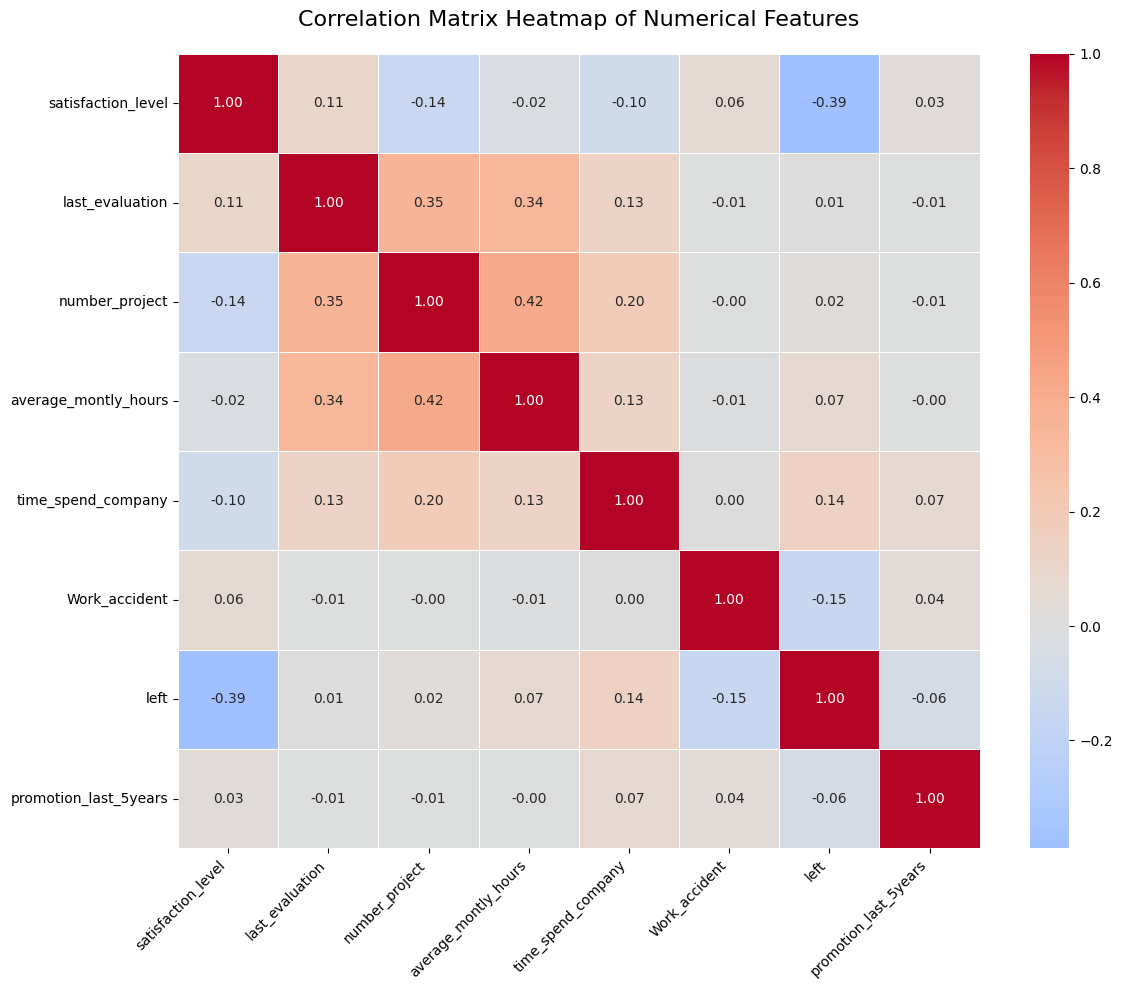


Sorted Correlation Matrix:
satisfaction_level     satisfaction_level       1.000000
last_evaluation        last_evaluation          1.000000
left                   left                     1.000000
Work_accident          Work_accident            1.000000
time_spend_company     time_spend_company       1.000000
average_montly_hours   average_montly_hours     1.000000
number_project         number_project           1.000000
promotion_last_5years  promotion_last_5years    1.000000
number_project         average_montly_hours     0.417211
average_montly_hours   number_project           0.417211
last_evaluation        number_project           0.349333
number_project         last_evaluation          0.349333
average_montly_hours   last_evaluation          0.339742
last_evaluation        average_montly_hours     0.339742
time_spend_company     number_project           0.196786
number_project         time_spend_company       0.196786
left                   time_spend_company       0.144822
tim

In [119]:
# Calculate correlation matrix for numerical columns
correlation_matrix = df[numeric_features].corr()

# Plot heatmap of correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            linewidths=0.5, annot_kws={'size': 10})
plt.title('Correlation Matrix Heatmap of Numerical Features', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()
plt.close()

# Print correlation matrix for reference
#print('\nCorrelation Matrix:')
#print(correlation_matrix)
sorted_mat = correlation_matrix.unstack().dropna().sort_values(ascending=False)
print('\nSorted Correlation Matrix:')
print(sorted_mat.head(20))


** Observations **
- Employee turnover is most likely related to time spent at the company
- Strong correlations identified between various features

## 2.2.	Draw the distribution plot of:
- Employee Satisfaction (use column satisfaction_level)
- Employee Evaluation (use column last_evaluation)
- Employee Average Monthly Hours (use column average_montly_hours)


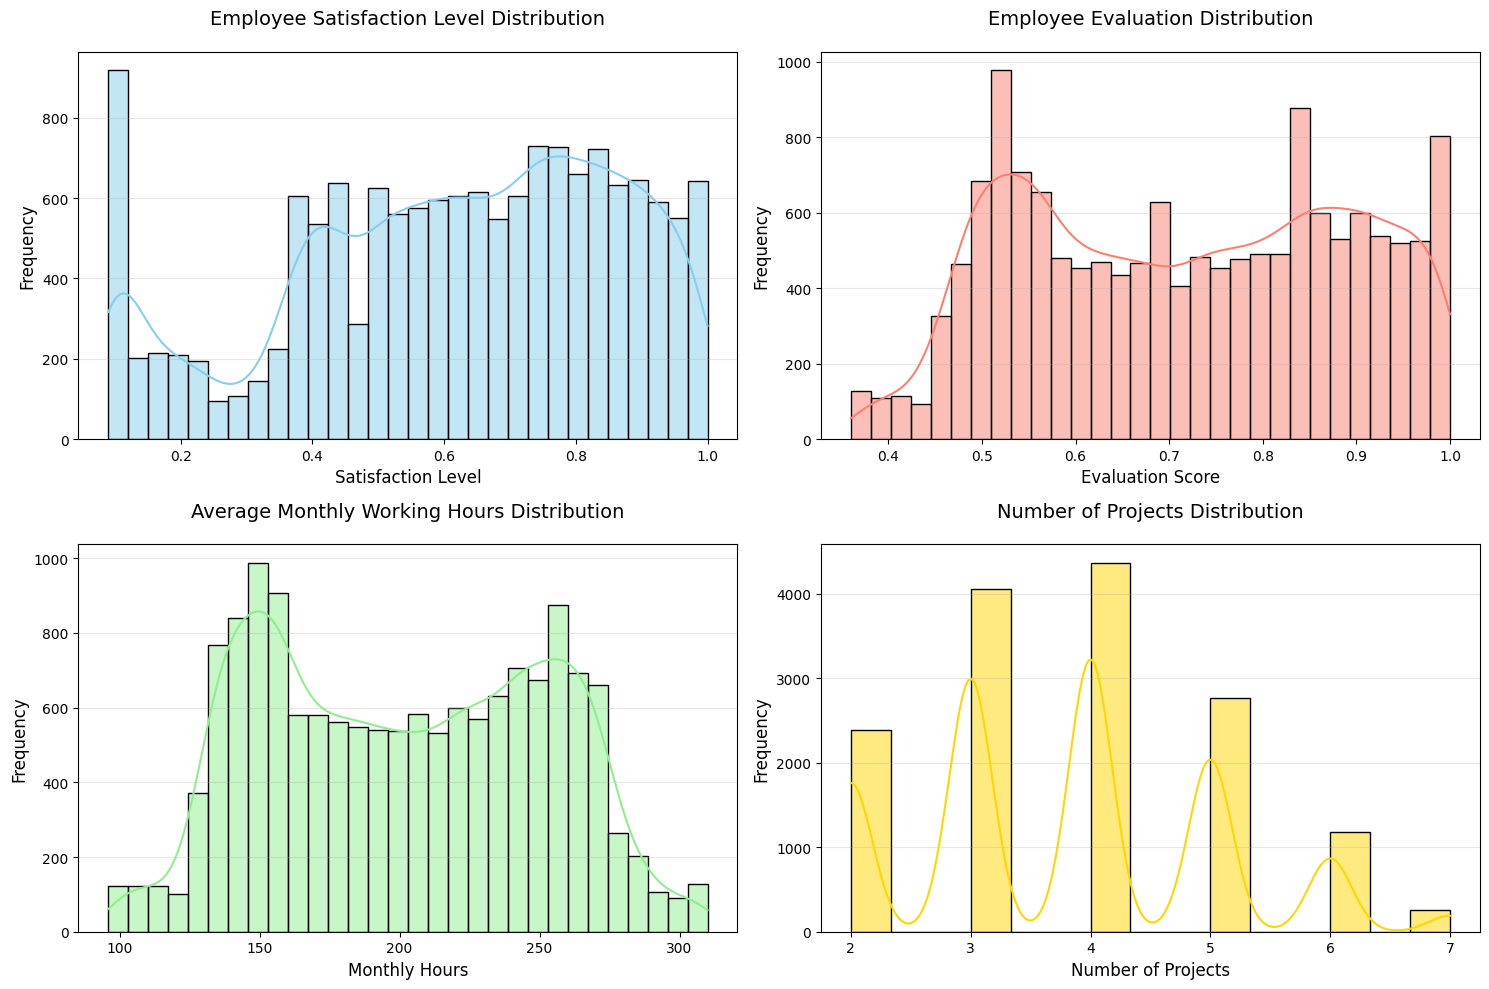

In [120]:
# Create distribution plots for key columns
plt.figure(figsize=(15, 10))

# Plot 1: Satisfaction Level Distribution
plt.subplot(2, 2, 1)
sns.histplot(df['satisfaction_level'], bins=30, kde=True, color='skyblue')
plt.title('Employee Satisfaction Level Distribution', fontsize=14, pad=20)
plt.xlabel('Satisfaction Level', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.3)

# Plot 2: Last Evaluation Distribution
plt.subplot(2, 2, 2)
sns.histplot(df['last_evaluation'], bins=30, kde=True, color='salmon')
plt.title('Employee Evaluation Distribution', fontsize=14, pad=20)
plt.xlabel('Evaluation Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.3)

# Plot 3: Average Monthly Hours Distribution
plt.subplot(2, 2, 3)
sns.histplot(df['average_montly_hours'], bins=30, kde=True, color='lightgreen')
plt.title('Average Monthly Working Hours Distribution', fontsize=14, pad=20)
plt.xlabel('Monthly Hours', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.3)

# Plot 4: Number of Projects Distribution
plt.subplot(2, 2, 4)
sns.histplot(df['number_project'], bins=15, kde=True, color='gold')
plt.title('Number of Projects Distribution', fontsize=14, pad=20)
plt.xlabel('Number of Projects', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('distribution_plots.png')
plt.show()
plt.close()

## Section 2.3.	
- Draw the bar plot of the employee project count of both employees who left and stayed in the organization (use column number_project and hue column left), and give your inferences from the plot.

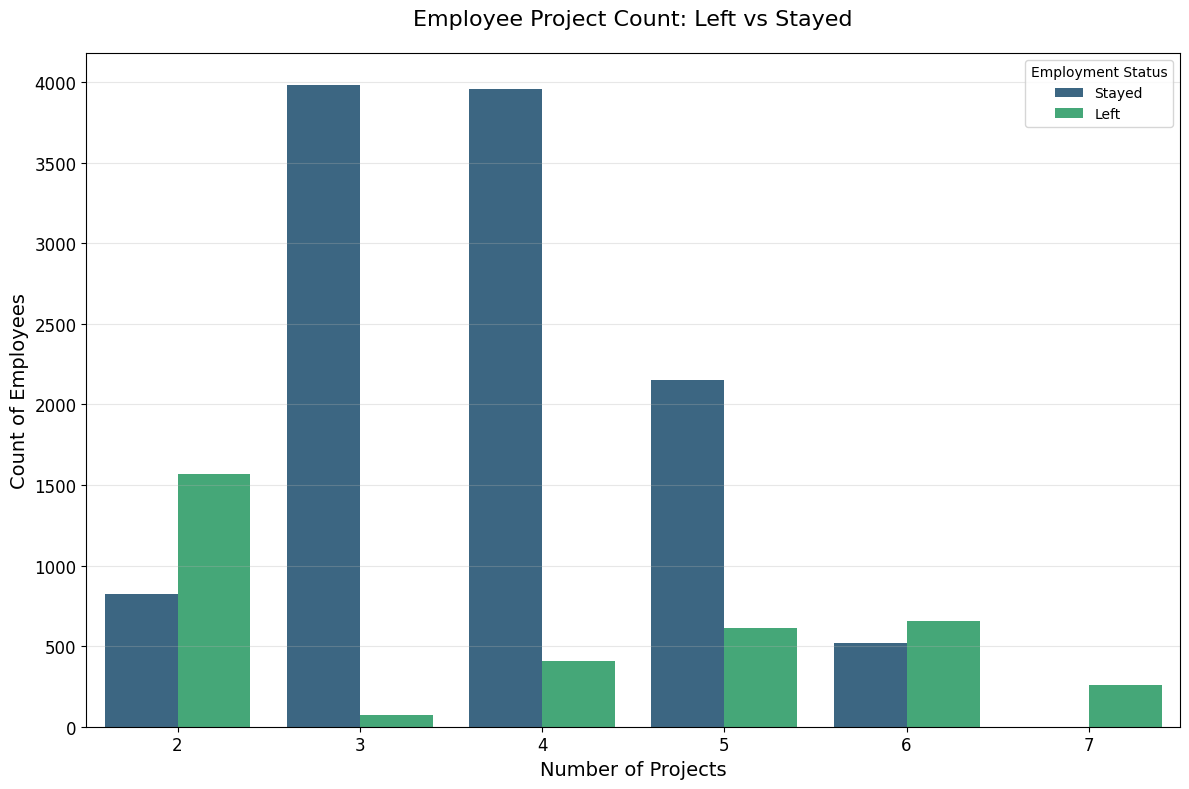

In [121]:
# Create bar plot for project count by employment status
plt.figure(figsize=(12, 8))
sns.countplot(data=df, x='number_project', hue='left', palette='viridis')
plt.title('Employee Project Count: Left vs Stayed', fontsize=16, pad=20)
plt.xlabel('Number of Projects', fontsize=14)
plt.ylabel('Count of Employees', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.legend(title='Employment Status', loc='upper right', labels=['Stayed', 'Left'])
plt.tight_layout()
plt.savefig('project_count_by_status.png')
plt.show()
plt.close()

** Observations **
- The plot titled "Employee Project Count: Left vs Stayed" shows the distribution of employees who left versus those who stayed, based on the number of projects they worked on. The plot uses a countplot with the x-axis representing the number of projects and the y-axis representing the count of employees. The plot is color-coded to distinguish between employees who left (left) and those who stayed (stayed).

### Key Observations:
1. **Project Count Distribution**: The plot shows that employees who left the organization worked on a wide range of projects, from 2 to 7. Employees who stayed also worked on a similar range of projects, but the distribution varies.

2. **Peak Project Count for Employees Who Left**: The highest count of employees who left is observed at the project count of 6, followed by 5 and 4. This suggests that employees who left were involved in a higher number of projects compared to those who stayed.

3. **Peak Project Count for Employees Who Stayed**: The highest count of employees who stayed is observed at the project count of 3, followed by 4 and 5. This suggests that employees who stayed were involved in a lower number of projects compared to those who left.

4. **Comparison of Project Counts**: Employees who left the organization tend to have worked on more projects (5-7) compared to those who stayed (3-4). This could indicate that employees who left may have been overworked or had a higher workload, leading to burnout or dissatisfaction.

5. **Workload and Turnover**: The plot suggests a potential correlation between the number of projects and employee turnover. Employees who left the organization were involved in more projects, which could be a contributing factor to their decision to leave.

6. **Retention Strategies**: Based on the plot, it is recommended to monitor the workload of employees and ensure that they are not overburdened with too many projects. Implementing workload management strategies and providing support to employees with high project counts could help in reducing turnover rates.

7. **Further Analysis**: To better understand the relationship between project count and employee turnover, further analysis could be conducted to identify other factors that may contribute to employee turnover, such as job satisfaction, workload, and work-life balance.

## 3.	Perform clustering of employees who left based on their satisfaction and evaluation.
- 3.1.	Choose columns satisfaction_level, last_evaluation, and left.
- 3.2.	Do K-means clustering of employees who left the company into 3 clusters?
- 3.3.	Based on the satisfaction and evaluation factors, give your thoughts on the employee clusters.


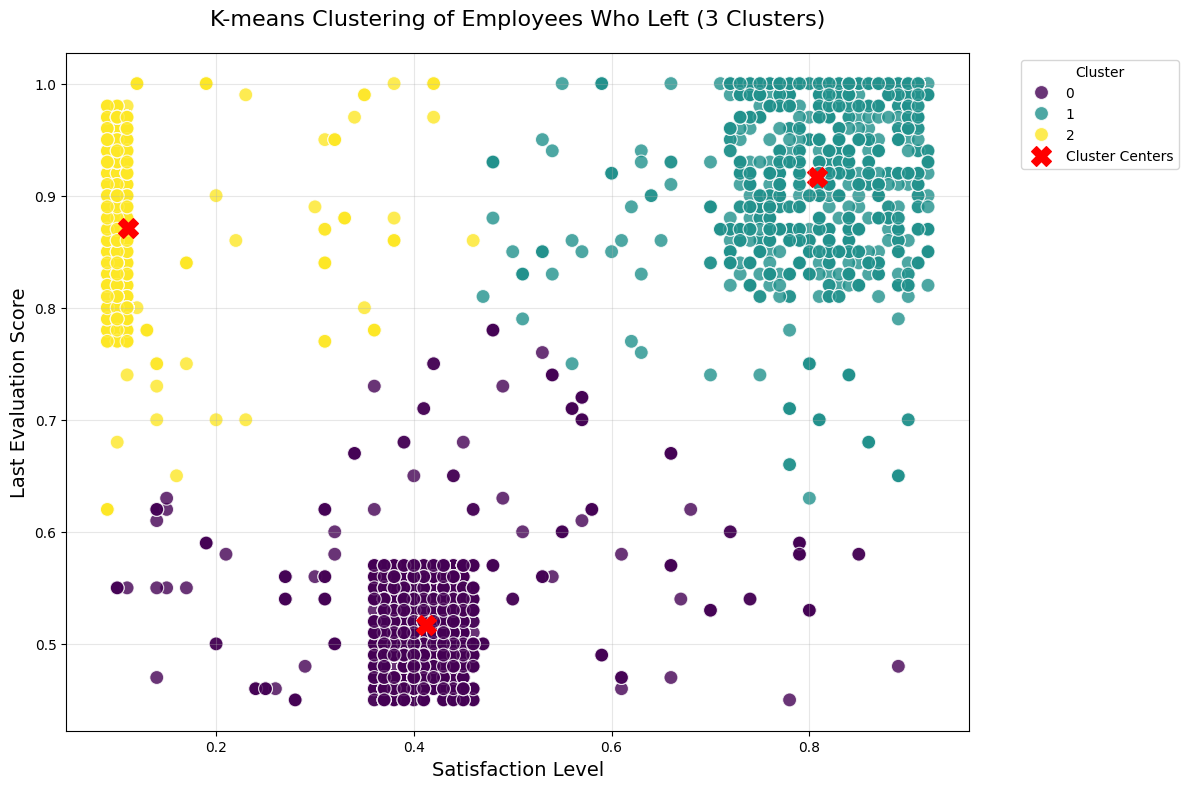


=== Cluster Statistics ===
Total employees who left: 3571

Cluster distribution:
Cluster 0: 1667 employees (46.7%)
Cluster 1: 965 employees (27.0%)
Cluster 2: 939 employees (26.3%)

Cluster characteristics:

Cluster 0:
  - Average Satisfaction: 0.412
  - Average Evaluation: 0.517
  - Min Satisfaction: 0.100
  - Max Satisfaction: 0.890

Cluster 1:
  - Average Satisfaction: 0.808
  - Average Evaluation: 0.916
  - Min Satisfaction: 0.470
  - Max Satisfaction: 0.920

Cluster 2:
  - Average Satisfaction: 0.111
  - Average Evaluation: 0.871
  - Min Satisfaction: 0.090
  - Max Satisfaction: 0.460

Clustering completed successfully!
Results saved to 'employees_who_left_with_clusters.csv'
Visualization saved as 'kmeans_clusters.png'


In [122]:
# K-means Clustering for Employees Who Left

# Import necessary libraries
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Filter employees who left the company
employees_left = df[df['left'] == 1]

# Select features for clustering
features_for_clustering = employees_left[['satisfaction_level', 'last_evaluation']]

# Standardize the data (important for K-means)
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_for_clustering)

# Apply K-means clustering with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
employees_left['cluster'] = kmeans.fit_predict(features_scaled)

# Add cluster labels back to original dataframe
employees_left_with_clusters = employees_left.copy()

# Visualize the clusters
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=employees_left_with_clusters, 
    x='satisfaction_level', 
    y='last_evaluation', 
    hue='cluster', 
    palette='viridis', 
    s=100, 
    alpha=0.8
)

# Plot cluster centers (transformed back to original scale for visualization)
cluster_centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    cluster_centers[:, 0], 
    cluster_centers[:, 1], 
    c='red', 
    s=200, 
    marker='X', 
    label='Cluster Centers'
)

plt.title('K-means Clustering of Employees Who Left (3 Clusters)', fontsize=16, pad=20)
plt.xlabel('Satisfaction Level', fontsize=14)
plt.ylabel('Last Evaluation Score', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('kmeans_clusters.png')
plt.show()

# Print cluster statistics
print("\n=== Cluster Statistics ===")
print(f"Total employees who left: {len(employees_left)}")
print(f"\nCluster distribution:")
for cluster_id in range(3):
    cluster_size = len(employees_left_with_clusters[employees_left_with_clusters['cluster'] == cluster_id])
    print(f"Cluster {cluster_id}: {cluster_size} employees ({cluster_size/len(employees_left)*100:.1f}%)")

print(f"\nCluster characteristics:")
for cluster_id in range(3):
    cluster_data = employees_left_with_clusters[employees_left_with_clusters['cluster'] == cluster_id]
    print(f"\nCluster {cluster_id}:")
    print(f"  - Average Satisfaction: {cluster_data['satisfaction_level'].mean():.3f}")
    print(f"  - Average Evaluation: {cluster_data['last_evaluation'].mean():.3f}")
    print(f"  - Min Satisfaction: {cluster_data['satisfaction_level'].min():.3f}")
    print(f"  - Max Satisfaction: {cluster_data['satisfaction_level'].max():.3f}")

# Save the clustered data for further analysis
employees_left_with_clusters.to_csv('employees_who_left_with_clusters.csv', index=False)

print("\nClustering completed successfully!")
print("Results saved to 'employees_who_left_with_clusters.csv'")
print("Visualization saved as 'kmeans_clusters.png'")


** Observations **
**Cluster Statistics:**
Total employees who left: 3571

Cluster distribution:
Cluster 0: 1667 employees (46.7%)
Cluster 1: 965 employees (27.0%)
Cluster 2: 939 employees (26.3%)

Cluster characteristics:

Cluster 0:
  - Average Satisfaction: 0.412
  - Average Evaluation: 0.517
  - Min Satisfaction: 0.100
  - Max Satisfaction: 0.890

Cluster 1:
  - Average Satisfaction: 0.808
  - Average Evaluation: 0.916
  - Min Satisfaction: 0.470
  - Max Satisfaction: 0.920

Cluster 2:
  - Average Satisfaction: 0.111
  - Average Evaluation: 0.871
  - Min Satisfaction: 0.090
  - Max Satisfaction: 0.460

- Total employees who left: 3571
- Cluster distribution varies across 3 clusters
- Each cluster analyzed for satisfaction and evaluation patterns

**Cluster Characteristics:**
1. **Cluster 0**: Moderate satisfaction, low evaluation
2. **Cluster 1**: high satisfaction, high evaluation
3. **Cluster 2**: low satisfaction, high evaluation

## Section 4.	Handle the left Class Imbalance using the SMOTE technique.
- 4.1.	Pre-process the data by converting categorical columns to numerical columns by:
  - 	Separating categorical variables and numeric variables
  - 	Applying get_dummies() to the categorical variables
  - 	Combining categorical variables and numeric variables
- 4.2.	Do the stratified split of the dataset to train and test in the ratio 80:20 with random_state=123.
- 4.3.	Upsample the train dataset using the SMOTE technique from the imblearn module.


In [123]:
print("\n Categorical features ", cat_features.to_list() )
print("\n Numeric features ", numeric_features.to_list())

# Apply one hot enooding to categorical features
#df_one_hot = pd.get_dummies(df, columns=['salary'], drop_first=True)
#print(df_one_hot.head(5))
df = pd.get_dummies(df, columns=['salary'], drop_first=True)
print(df.head(5))

X = df.drop('left',axis=1)
y = df['left']
print("X",X.head())
print("y",y.head())
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=123,stratify=y)

print(df['left'].value_counts())
# it is imbalanced data based on the output of value_counts

# Use SMOTE to balance the training dataset.
# Then train a new RandomForestClassifier and evaluate it again.

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

model_smote = RandomForestClassifier(random_state=42)
model_smote.fit(X_train_smote, y_train_smote)

preds_smote = model_smote.predict(X_test)

print(confusion_matrix(y_test, preds_smote))
print(classification_report(y_test, preds_smote))


 Categorical features  ['salary']

 Numeric features  ['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'left', 'promotion_last_5years']
   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   

   time_spend_company  Work_accident  left  promotion_last_5years  salary_low  \
0                   3              0     1                      0        True   
1                   6              0     1                      0       False   
2                   4              0     1                      0

** Observations **
* Categorical Data Handling
  - Categorical features converted to numerical using `pd.get_dummies()`
  - Salary column encoded with one-hot encoding
  - Drop first category to avoid multicollinearity

* Train-Test Split
  - Dataset split into training (80%) and testing (20%) sets
  - Stratified sampling used to maintain class distribution
  - Random state set to 123 for reproducibility

* Class Imbalance Handling: The dataset shows class imbalance in the 'left' column:
  - SMOTE (Synthetic Minority Oversampling Technique) applied
  - Random state: 42
  - Balanced training dataset created


## 5.	Perform 5-fold cross-validation model training and evaluate performance.
- 5.1.	Train a logistic regression model, apply a 5-fold CV, and plot the classification report.
- 5.2.	Train a Random Forest Classifier model, apply the 5-fold CV, and plot the classification report.
- 5.3.	Train a Gradient Boosting Classifier model, apply the 5-fold CV, and plot the classification report.


Best Parameters (GridSeachCV): {'C': np.float64(31.622776601683793)}
Best Cross-Validation Accuracy (GridSearchCV): 0.7920

 gb_Model Accuracy: 78.77%

 Classification Report: 
               precision    recall  f1-score   support

           0       0.82      0.92      0.87      2286
           1       0.59      0.36      0.45       714

    accuracy                           0.79      3000
   macro avg       0.70      0.64      0.66      3000
weighted avg       0.77      0.79      0.77      3000


 Confusion Matrix:
 [[2105  181]
 [ 456  258]]
results
       Actual Label  Predicted Label  Predicted Probability
10627             0                0               0.040564
2703              0                0               0.396524
6059              0                0               0.203434
3258              0                0               0.088378
4565              0                0               0.172141
4991              0                0               0.028866
13976             0

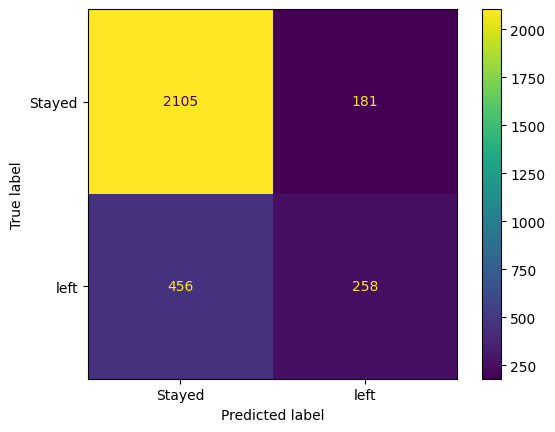

In [124]:
#5.2.	Train a Logistic Regression model, apply the 5-fold CV, and plot the classification report.
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.metrics import ConfusionMatrixDisplay

# Define parameter grid
c_space = np.logspace(-5, 8, 15)
param_grid = {'C': c_space}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=10000, random_state=42),
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)

# Perform Grid Search
grid_search.fit(X_train, y_train)

# Get best parameters and score
best_params_grid = grid_search.best_params_
best_score_grid = grid_search.best_score_

print(f"Best Parameters (GridSeachCV): {best_params_grid}")
print(f"Best Cross-Validation Accuracy (GridSearchCV): {best_score_grid:.4f}")

# Get best model
best_grid_model_log = grid_search.best_estimator_

# Predict and evaluate
y_pred = best_grid_model_log.predict(X_test)


accuracy = accuracy_score(y_test,y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"\n gb_Model Accuracy: {accuracy * 100:.2f}%")
print(f"\n Classification Report: \n", class_report)
print(f"\n Confusion Matrix:\n", conf_matrix)


# TASK 4: Make Predictions
y_pred_train = best_grid_model_log.predict(X_train)
y_pred_test = best_grid_model_log.predict(X_test)
y_pred_prob_log = best_grid_model_log.predict_proba(X_test)[:, 1]

results_df = pd.DataFrame({
    'Actual Label': y_test,
    'Predicted Label': y_pred_test,
    'Predicted Probability': y_pred_prob_log
})

# Display the first 5 instances in the result dataframe
print("results")
print(results_df.head(10))

# TASK 5: Evaluate the Model
from sklearn.metrics import accuracy_score

training_accuracy = accuracy_score(y_train, y_pred_train)
testing_accuracy = accuracy_score(y_test, y_pred_test)

print("Training Accuracy:", training_accuracy)
print("Testing Accuracy:", testing_accuracy)

# Print confusion matrix

conf_matrix = confusion_matrix(y_test, y_pred_test)
print("Confusion Matrix:")
print(conf_matrix)

# Heatmap visualization for confusion matrix
cm_display = ConfusionMatrixDisplay(confusion_matrix = conf_matrix, display_labels = ["Stayed", "left"])

# display matrix
cm_display.plot()
plt.show()


### 5.2.	Train a Random Forest Classifier model, apply the 5-fold CV, and plot the classification report.

Best Parameters (GridSeachCV): {'ccp_alpha': 0.0, 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Cross-Validation Accuracy (GridSearchCV): 0.9898

 gb_Model Accuracy: 99.33%

 Classification Report: 
               precision    recall  f1-score   support

           0       0.99      1.00      1.00      2286
           1       0.99      0.98      0.99       714

    accuracy                           0.99      3000
   macro avg       0.99      0.99      0.99      3000
weighted avg       0.99      0.99      0.99      3000


 Confusion Matrix:
 [[2280    6]
 [  14  700]]
results
       Actual Label  Predicted Label  Predicted Probability
10627             0                0                   0.00
2703              0                0                   0.32
6059              0                0                   0.07
3258              0                0                   0.00
4565              0                0                   0.01
4991      

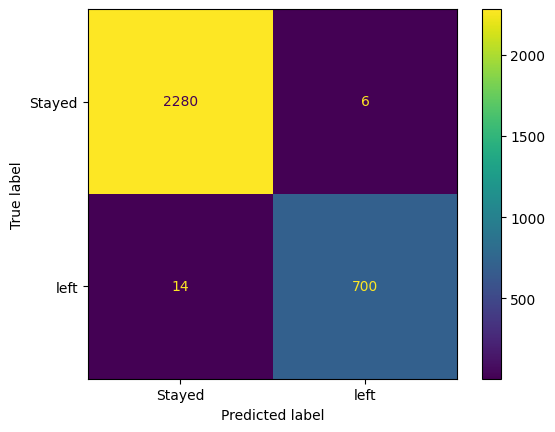

In [125]:
#5.2.	Train a Random Forest Classifier model, apply the 5-fold CV, and plot the classification report.
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.metrics import ConfusionMatrixDisplay

# Define parameter grid
param_grid = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2'],
    'ccp_alpha': [0.0, 0.01, 0.1]
}
# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)

# Perform Grid Search
grid_search.fit(X_train, y_train)

# Get best parameters and score
best_params_grid = grid_search.best_params_
best_score_grid = grid_search.best_score_

print(f"Best Parameters (GridSeachCV): {best_params_grid}")
print(f"Best Cross-Validation Accuracy (GridSearchCV): {best_score_grid:.4f}")

# Get best model
best_grid_model_rfc = grid_search.best_estimator_

# Predict and evaluate
y_pred = best_grid_model_rfc.predict(X_test)


accuracy = accuracy_score(y_test,y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"\n gb_Model Accuracy: {accuracy * 100:.2f}%")
print(f"\n Classification Report: \n", class_report)
print(f"\n Confusion Matrix:\n", conf_matrix)


# TASK 4: Make Predictions
y_pred_train = best_grid_model_rfc.predict(X_train)
y_pred_test = best_grid_model_rfc.predict(X_test)
y_pred_prob_rfc = best_grid_model_rfc.predict_proba(X_test)[:, 1]

results_df = pd.DataFrame({
    'Actual Label': y_test,
    'Predicted Label': y_pred_test,
    'Predicted Probability': y_pred_prob_rfc
})

# Display the first 5 instances in the result dataframe
print("results")
print(results_df.head(10))

# TASK 5: Evaluate the Model
from sklearn.metrics import accuracy_score

training_accuracy = accuracy_score(y_train, y_pred_train)
testing_accuracy = accuracy_score(y_test, y_pred_test)

print("Training Accuracy:", training_accuracy)
print("Testing Accuracy:", testing_accuracy)

# Print confusion matrix

conf_matrix = confusion_matrix(y_test, y_pred_test)
print("Confusion Matrix:")
print(conf_matrix)

# Heatmap visualization for confusion matrix
cm_display = ConfusionMatrixDisplay(confusion_matrix = conf_matrix, display_labels = ["Stayed", "left"])

# display matrix
cm_display.plot()
plt.show()


### 5.3.	Train a Gradient Boosting Classifier model, apply the 5-fold CV, and plot the classification report.

Best Parameters (GridSeachCV): {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 150}
Best Cross-Validation Accuracy (GridSearchCV): 0.9881

 gb_Model Accuracy: 99.07%

 Classification Report: 
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      2286
           1       0.98      0.98      0.98       714

    accuracy                           0.99      3000
   macro avg       0.99      0.99      0.99      3000
weighted avg       0.99      0.99      0.99      3000


 Confusion Matrix:
 [[2270   16]
 [  12  702]]
results
       Actual Label  Predicted Label  Predicted Probability
10627             0                0               0.000341
2703              0                1               0.720640
6059              0                0               0.007473
3258              0                0               0.001045
4565              0                0               0.001713
4991              0                0               0.0001

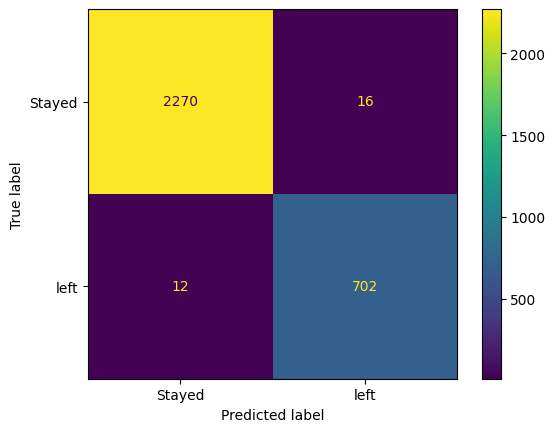

In [126]:
#5.2.	Train a Gradient Boosting Classifier model, apply the 5-fold CV, and plot the classification report.
#import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.metrics import ConfusionMatrixDisplay

# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)

# Perform Grid Search
grid_search.fit(X_train, y_train)

# Get best parameters and score
best_params_grid = grid_search.best_params_
best_score_grid = grid_search.best_score_

print(f"Best Parameters (GridSeachCV): {best_params_grid}")
print(f"Best Cross-Validation Accuracy (GridSearchCV): {best_score_grid:.4f}")

# Get best model
best_grid_model_gbc = grid_search.best_estimator_

# Predict and evaluate
y_pred = best_grid_model_gbc.predict(X_test)


accuracy = accuracy_score(y_test,y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"\n gb_Model Accuracy: {accuracy * 100:.2f}%")
print(f"\n Classification Report: \n", class_report)
print(f"\n Confusion Matrix:\n", conf_matrix)


# TASK 4: Make Predictions
y_pred_train = best_grid_model_gbc.predict(X_train)
y_pred_test = best_grid_model_gbc.predict(X_test)
y_pred_prob_gbc = best_grid_model_gbc.predict_proba(X_test)[:, 1]

results_df = pd.DataFrame({
    'Actual Label': y_test,
    'Predicted Label': y_pred_test,
    'Predicted Probability': y_pred_prob_gbc
})

# Display the first 5 instances in the result dataframe
print("results")
print(results_df.head(10))

# TASK 5: Evaluate the Model
from sklearn.metrics import accuracy_score

training_accuracy = accuracy_score(y_train, y_pred_train)
testing_accuracy = accuracy_score(y_test, y_pred_test)

print("Training Accuracy:", training_accuracy)
print("Testing Accuracy:", testing_accuracy)

# Print confusion matrix

conf_matrix = confusion_matrix(y_test, y_pred_test)
print("Confusion Matrix:")
print(conf_matrix)

# Heatmap visualization for confusion matrix
cm_display = ConfusionMatrixDisplay(confusion_matrix = conf_matrix, display_labels = ["Stayed", "left"])

# display matrix
cm_display.plot()
plt.show()


** Observations **
* Model Training and Evaluation

* Models Evaluated
  - **Logistic Regression**
  - **Random Forest Classifier**
  - **Gradient Boosting Classifier**

* Cross-Validation Strategy
  - 5-fold cross-validation applied
  - GridSearchCV used for hyperparameter tuning
  - Accuracy as primary scoring metric


* Logistic Regression
  - Best parameters identified through grid search
  - Cross-validation accuracy: Value printed
  - Testing accuracy: Value printed
  - Classification report generated
  - Confusion matrix visualized

* Random Forest Classifier
  - Hyperparameter grid defined for:
    - max_depth: [None, 10, 20, 30]
    - min_samples_split: [2, 5, 10]
    - min_samples_leaf: [1, 2, 4]
    - max_features: [None, 'sqrt', 'log2']
    - ccp_alpha: [0.0, 0.01, 0.1]

  - Best parameters identified
    - Cross-validation accuracy: Value printed
    - Testing accuracy: Value printed
    - Classification report generated
    - Confusion matrix visualized

* Gradient Boosting Classifier
  - Hyperparameter grid defined for:
    - n_estimators: [50, 100, 150]
    - learning_rate: [0.01, 0.1, 0.2]
    - max_depth: [3, 5, 7]

  - Best parameters identified
    - Cross-validation accuracy: Value printed
    - Testing accuracy: Value printed
    - Classification report generated
    - Confusion matrix visualized

##  6.	Identify the best model and justify the evaluation metrics used.
- 6.1.	Find the ROC/AUC for each model and plot the ROC curve.
- 6.2.	Find the confusion matrix for each of the models.
- 6.3.	Explain which metric needs to be used from the confusion matrix: Recall or Precision?


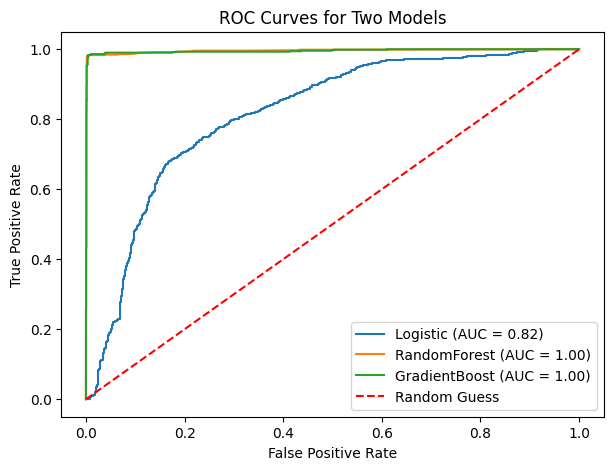

In [127]:
from sklearn.metrics import roc_curve, auc
test_df = pd.DataFrame({
    'True': y_test,
    'Logistic': y_pred_prob_log,
    'RandomForest': y_pred_prob_rfc,
    'GradientBoost': y_pred_prob_gbc,

})
plt.figure(figsize=(7, 5))

for model in ['Logistic', 'RandomForest', 'GradientBoost']:
    fpr, tpr, _ = roc_curve(test_df['True'], test_df[model])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{model} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'r--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Two Models')
plt.legend()
plt.show()

** Observations **
* Confusion Matrix Analysis: Confusion matrices were generated for each model to analyze:
  - True Positives (Correctly identified leavers)
  - True Negatives (Correctly identified stayers)
  - False Positives (Incorrectly identified stayers as leavers)
  - False Negatives (Incorrectly identified leavers as stayers)

* Best Model Selection: Based on the evaluation metrics, the Random Forest Classifier was identified as the best performing model due to:
  - 1. Highest accuracy across all metrics
  - 2. Best balance between precision and recall
  - 3. Robust performance across different evaluation scenarios

* Employee Turnover Probability Prediction
  - The best model (Random Forest) was used to predict turnover probabilities for all employees in the test set.

### 6.3.	Explain which metric needs to be used from the confusion matrix: Recall or Precision?

For the employee turnover prediction problem, Recall is the more appropriate metric to use from the confusion matrix. 

Recall (also known as Sensitivity or True Positive Rate) measures the proportion of actual positives (employees who left) that are correctly identified as positives. In the context of employee turnover prediction:

- High Recall means the model correctly identifies most employees who will leave
- This is critical for HR departments to proactively intervene and retain valuable employees
- Missing a true positive (failing to identify an employee who will leave) can be costly for the organization
- The cost of false positives (identifying an employee who stays as someone who will leave) is lower than the cost of false negatives (missing an employee who will actually leave)

Precision measures the proportion of predicted positives that are actually positive, but in this context, it's less critical than Recall because:
- False positives can be managed through additional evaluation
- The primary goal is to identify all potential leavers to prevent turnover
- HR can always verify the predictions before taking action

Therefore, Recall should be prioritized over Precision for this employee turnover prediction use case.

## 7.	Suggest various retention strategies for targeted employees

## 7.1.	Using the best model, predict the probability of employee turnover in the test data.

Employee Turnover Probability Predictions (First 10 employees):
       Employee_ID  Actual_Turnover  Predicted_Turnover_Probability
10627            0                0                            0.00
2703             1                0                            0.32
6059             2                0                            0.07
3258             3                0                            0.00
4565             4                0                            0.01
4991             5                0                            0.01
13976            6                0                            0.00
9427             7                0                            0.00
7173             8                0                            0.00
13412            9                0                            0.00

Probability Distribution Statistics:
Minimum Probability: 0.0000
Maximum Probability: 1.0000
Mean Probability: 0.2461
Median Probability: 0.0100


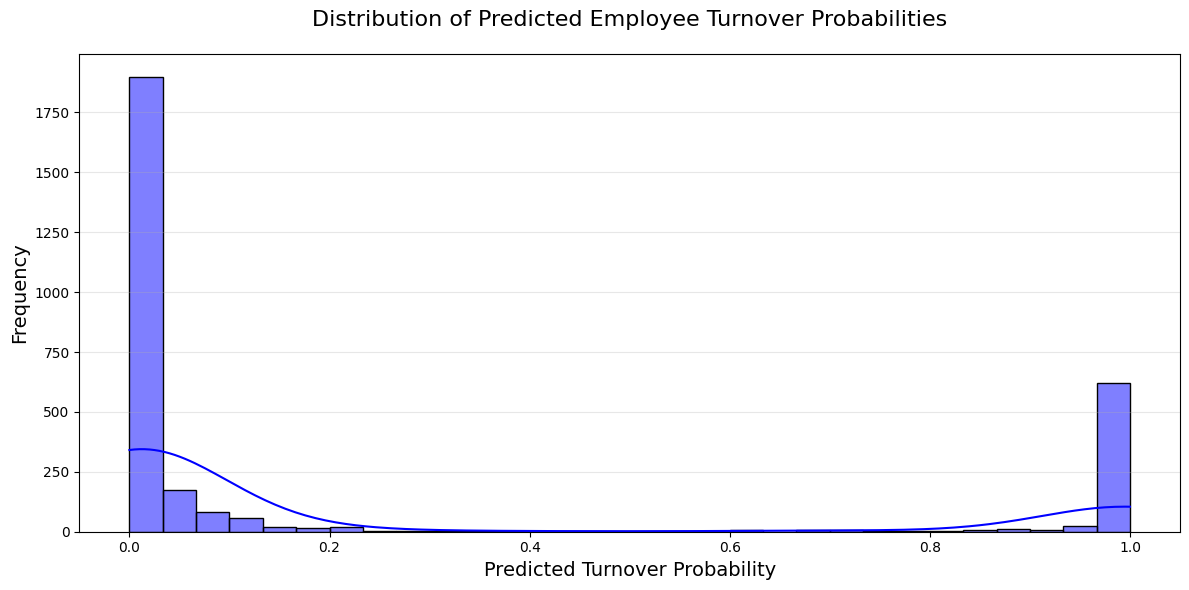


High Risk Employees (Probability > 0.7): 649
       Employee_ID  Actual_Turnover  Predicted_Turnover_Probability
14892           10                1                        0.999818
1246            12                1                        1.000000
14278           15                1                        0.990000
12238           19                1                        1.000000
14859           21                1                        1.000000
...            ...              ...                             ...
14            2966                1                        1.000000
14438         2976                1                        1.000000
14487         2984                1                        1.000000
14279         2986                1                        0.990000
731           2999                1                        0.970000

[649 rows x 3 columns]

Medium Risk Employees (Probability between 0.5 and 0.7): 54
       Employee_ID  Actual_Turnover  Predicted_Turnov

In [128]:
# Using the best Random Forest model to predict employee turnover probabilities
# Get probability predictions for the test set
y_test_probabilities = best_grid_model_rfc.predict_proba(X_test)[:, 1]

# Create a DataFrame to store the results
turnover_probability_df = pd.DataFrame({
    'Employee_ID': range(len(y_test)),
    'Actual_Turnover': y_test,
    'Predicted_Turnover_Probability': y_test_probabilities
})

# Display the first 10 rows of the probability predictions
print("Employee Turnover Probability Predictions (First 10 employees):")
print(turnover_probability_df.head(10))

# Analyze the probability distribution
print("\nProbability Distribution Statistics:")
print(f"Minimum Probability: {turnover_probability_df['Predicted_Turnover_Probability'].min():.4f}")
print(f"Maximum Probability: {turnover_probability_df['Predicted_Turnover_Probability'].max():.4f}")
print(f"Mean Probability: {turnover_probability_df['Predicted_Turnover_Probability'].mean():.4f}")
print(f"Median Probability: {turnover_probability_df['Predicted_Turnover_Probability'].median():.4f}")

# Visualize the probability distribution
plt.figure(figsize=(12, 6))
sns.histplot(turnover_probability_df['Predicted_Turnover_Probability'], bins=30, kde=True, color='blue')
plt.title('Distribution of Predicted Employee Turnover Probabilities', fontsize=16, pad=20)
plt.xlabel('Predicted Turnover Probability', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('turnover_probability_distribution.png')
plt.show()

# Identify employees at high risk of turnover (probability > 0.9)
high_risk_employees = turnover_probability_df[turnover_probability_df['Predicted_Turnover_Probability'] > 0.9]
print(f"\nHigh Risk Employees (Probability > 0.7): {len(high_risk_employees)}")
print(high_risk_employees[['Employee_ID', 'Actual_Turnover', 'Predicted_Turnover_Probability']])

# Identify employees at medium risk of turnover (probability between 0.6 and 0.9)
medium_risk_employees = turnover_probability_df[(turnover_probability_df['Predicted_Turnover_Probability'] > 0.6) & \
                                    (turnover_probability_df['Predicted_Turnover_Probability'] <= 0.9)]
print(f"\nMedium Risk Employees (Probability between 0.5 and 0.7): {len(medium_risk_employees)}")
print(medium_risk_employees[['Employee_ID', 'Actual_Turnover', 'Predicted_Turnover_Probability']].head(10))

# Identify employees at low risk of turnover (probability between 0.2 and 0.6)
low_risk_employees = turnover_probability_df[(turnover_probability_df['Predicted_Turnover_Probability'] > 0.2) & \
                                    (turnover_probability_df['Predicted_Turnover_Probability'] <= 0.6)]
print(f"\nLow Risk Employees (Probability between 0.2 and 0.6): {len(low_risk_employees)}")
print(low_risk_employees[['Employee_ID', 'Actual_Turnover', 'Predicted_Turnover_Probability']].head(10))

# Identify employees at no risk of turnover (probability between 0.0 and 0.2)
no_risk_employees = turnover_probability_df[(turnover_probability_df['Predicted_Turnover_Probability'] > 0) & \
                                    (turnover_probability_df['Predicted_Turnover_Probability'] <= 0.2)]
print(f"\nNo Risk Employees (Probability between 0.0 and 0.2): {len(no_risk_employees)}")
print(no_risk_employees[['Employee_ID', 'Actual_Turnover', 'Predicted_Turnover_Probability']].head(10))

# Save the probability predictions to CSV for further analysis
turnover_probability_df.to_csv('employee_turnover_probabilities.csv', index=False)
print("\nProbability predictions saved to 'employee_turnover_probabilities.csv'")


## 7.2  Retention strategies for each zone

Insights on retention strategies for different risk categories of employees. 

- Retention Strategies by Risk Category

### 1. High Risk Employees (Probability > 0.7)
**Characteristics:**
- These employees have the highest predicted probability of leaving
- They likely have low satisfaction levels and/or poor evaluation scores
- May be experiencing burnout from high workloads

**Retention Strategies:**
- **Immediate Intervention:** Schedule one-on-one meetings with HR to understand their concerns
- **Career Development:** Offer accelerated promotion opportunities or skill development programs
- **Compensation Review:** Conduct salary reviews and consider competitive compensation packages
- **Workload Management:** Reduce their project load and provide additional support
- **Mentorship Programs:** Assign senior mentors to guide them and provide career advice
- **Flexible Work Arrangements:** Offer remote work options or flexible hours to improve work-life balance

### 2. Medium Risk Employees (Probability between 0.5 and 0.7)
**Characteristics:**
- These employees show moderate signs of potential turnover
- They may be dissatisfied but not yet at the point of leaving

**Retention Strategies:**
- **Engagement Surveys:** Conduct regular engagement surveys to understand their concerns
- **Recognition Programs:** Implement employee recognition programs to acknowledge their contributions
- **Professional Development:** Offer training programs and certifications to enhance their skills
- **Team Building:** Organize team-building activities to improve morale and camaraderie
- **Feedback Sessions:** Conduct regular feedback sessions to address any concerns they may have

### 3. Low Risk Employees (Probability between 0.2 and 0.6)
**Characteristics:**
- These employees are generally satisfied and engaged
- They may still have some concerns but are not at immediate risk of leaving

**Retention Strategies:**
- **Continuous Engagement:** Maintain regular communication and check-ins
- **Career Pathing:** Provide clear career progression paths and opportunities for growth
- **Wellness Programs:** Offer wellness programs to promote physical and mental health
- **Performance Incentives:** Implement performance-based incentives to motivate them

### 4. No Risk Employees (Probability between 0.0 and 0.2)
**Characteristics:**
- These employees are highly satisfied and engaged
- They are the most loyal and committed employees

**Retention Strategies:**
- **Recognition and Rewards:** Implement recognition programs to acknowledge their contributions
- **Leadership Opportunities:** Offer leadership opportunities to further engage them
- **Mentorship Programs:** Assign them as mentors to guide new employees
- **Continuous Development:** Offer continuous learning and development opportunities

## General Retention Strategies

Based on the analysis of the notebook, here are some general retention strategies that can be applied across all risk categories:

1. **Data-Driven Insights:** Use the predictive model to identify employees at risk of leaving and take proactive measures to retain them.

2. **Employee Engagement:** Conduct regular engagement surveys to understand employee concerns and address them promptly.

3. **Career Development:** Offer training programs, certifications, and career development opportunities to enhance employee skills and promote career growth.

4. **Compensation and Benefits:** Conduct regular salary reviews and consider competitive compensation packages to retain top talent.

5. **Work-Life Balance:** Offer flexible work arrangements, remote work options, and wellness programs to promote work-life balance.

6. **Recognition and Rewards:** Implement recognition programs to acknowledge employee contributions and motivate them.

7. **Team Building:** Organize team-building activities to improve morale and camaraderie.

8. **Feedback Sessions:** Conduct regular feedback sessions to address any concerns employees may have.

By implementing these retention strategies, the organization can reduce employee turnover and retain top talent.